# Kampala Air Quality and TB Analysis - Full Dataset Pipeline


In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from datetime import date
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import sys
sys.path.append('./src')

from simplified_data_processor import SimplifiedDataProcessor
from intervention_simulator import InterventionSimulator
from time_series_modeler import TimeSeriesModeler
from visualizer import Visualizer
from report_generator import ReportGenerator

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All modules imported successfully")

import warnings
warnings.filterwarnings('ignore')


✓ All modules imported successfully


In [31]:
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

main_df = pd.merge(
    clim_df,
    plo_df,
    left_on=['epi_year', 'epi_week'],
    right_on=['year', 'week'],
    how='inner'
)

drop_cols = ['year', 'week']
main_df.drop(columns=drop_cols, inplace=True)

# Function to get the last day (Sunday) of each ISO week
def get_last_day_of_week(year, week):
    return date.fromisocalendar(int(year), int(week), 7)

# Apply function to create a proper date column
main_df['date'] = main_df.apply(
    lambda row: get_last_day_of_week(row['epi_year'], row['epi_week']),
    axis=1
)

main_df['date'] = pd.to_datetime(main_df['date'])   # ensure datetime dtype

# Extract the last date (Sunday) from periodname
resp_df['date'] = resp_df['periodname'].str.extract(r'-\s*(\d{4}-\d{2}-\d{2})')
resp_df['date'] = pd.to_datetime(resp_df['date'], errors='coerce')

# Keep ALL columns (not just TB)
resp_df = resp_df.drop(columns=['periodname'])  # drop only the text period column


In [32]:

# --- Merge climate + TB + other health indicators ---
merged_df = pd.merge(main_df, resp_df, on='date', how='inner')


# Rename climate columns to match processor expectations
rename_map = {
    'weekly_pm25_avg': 'pm2_5',
    'weekly_temp_avg': 'avgtemp',
    'weekly_humidity_avg': 'avghumidity',
    'Pulmonary TB cases': 'TB',
    'Avg_Temp(C)': 'avgtemp_sat',
    'AvgWindspeed(m/s)': 'windspeed',
    'AvgPrecipitation(mm/day)': 'precip',
    'AvgRelative_Humidity(%)': 'humidity_sat',
    'ILI Cases': 'ILI',
    'ILD deaths': 'ILD_deaths',
    'Severe pneumonia under 5 Cases': 'pneumonia_u5',
    'Severe pneumonia under 5 deaths': 'pneumonia_u5_deaths',
    'SARI Cases': 'SARI',
    'SARI Deaths': 'SARI_deaths'
}

merged_df.rename(columns=rename_map, inplace=True)

In [33]:
# Select the columns you want to impute
cols_to_impute = ['pm2_5', 'avgtemp', 'avghumidity', 'TB']

imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent'
merged_df[cols_to_impute] = imputer.fit_transform(merged_df[cols_to_impute])

# Save merged dataset
merged_df.to_csv('data/merged_climate_tb_data.csv', index=False)

In [34]:
# ## Step 1: Load and Process Data

# %%
# Initialize data processor
processor = SimplifiedDataProcessor(data_dir='../data')

# Load the merged data
data = processor.load_data('./data/merged_climate_tb_data.csv')
print(f"✓ Loaded data: {len(data)} records")

INFO:simplified_data_processor:SimplifiedDataProcessor initialized with data directory: ..\data
INFO:simplified_data_processor:Loading data from ./data/merged_climate_tb_data.csv
INFO:simplified_data_processor:Loaded 248 records
INFO:simplified_data_processor:Data processing complete: 248 records


✓ Loaded data: 248 records


In [35]:
# Add lag features and rolling averages
processed_data = processor.add_lag_features()

# Add extra engineered features so they pass through the same initial pipeline
processed_data['date'] = pd.to_datetime(processed_data['date'], errors='coerce', dayfirst=True)
processed_data['temp_humidity_interaction'] = processed_data['avgtemp'] * processed_data['avghumidity']
processed_data['temp_sat_gap'] = processed_data['avgtemp'] - processed_data.get('avgtemp_sat', processed_data['avgtemp'])
processed_data['humidity_sat_gap'] = processed_data['avghumidity'] - processed_data.get('humidity_sat', processed_data['avghumidity'])
processed_data['precip_rolling_4'] = processed_data['precip'].rolling(window=4, min_periods=1).mean()
processed_data['windspeed_rolling_4'] = processed_data['windspeed'].rolling(window=4, min_periods=1).mean()
processed_data['pm25_temp_ratio'] = processed_data['pm2_5'] / (processed_data['avgtemp'].abs() + 1)
processed_data['pm25_humidity_ratio'] = processed_data['pm2_5'] / (processed_data['avghumidity'].abs() + 1)
processed_data['tb_pct_change_1'] = processed_data['TB'].pct_change().replace([np.inf, -np.inf], np.nan)
processed_data['tb_diff_1'] = processed_data['TB'].diff()
processed_data['sin_week'] = np.sin(2 * np.pi * processed_data['week_of_year'] / 52)
processed_data['cos_week'] = np.cos(2 * np.pi * processed_data['week_of_year'] / 52)
processed_data['sin_month'] = np.sin(2 * np.pi * processed_data['month'] / 12)
processed_data['cos_month'] = np.cos(2 * np.pi * processed_data['month'] / 12)

print(f"✓ Added features: {processed_data.shape[1]} total columns")

INFO:simplified_data_processor:Added lag features and rolling averages


✓ Added features: 68 total columns


In [36]:
# Get summary statistics
summary = processor.get_summary_statistics()
print("\nData Summary:")
print(f"- Date range: {summary['date_range']}")
print(f"- Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"- Total TB cases: {summary['tb_statistics']['total_cases']}")
print(f"- PM2.5-TB correlation: {summary['correlation_pm25_tb']:.3f}")



Data Summary:
- Date range: 2020-01-05 00:00:00 to 2024-12-15 00:00:00
- Average PM2.5: 39.28 μg/m³
- Total TB cases: 158287.77142857143
- PM2.5-TB correlation: -0.017


In [37]:
# Display first few rows including diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
preview_cols = [
    'date', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + disease_cols + [
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'sin_week', 'cos_week', 'sin_month', 'cos_month'
]
preview_cols = [col for col in preview_cols if col in processed_data.columns]
processed_data[preview_cols].head(10)


,date,pm2_5,avgtemp,avghumidity,windspeed,precip,TB,ILI,ILD_deaths,pneumonia_u5,...,precip_rolling_4,windspeed_rolling_4,pm25_temp_ratio,pm25_humidity_ratio,tb_pct_change_1,tb_diff_1,sin_week,cos_week,sin_month,cos_month
0,2020-01-05,43.77,24.45,72.79,2.08,2.52,7.0,NaN,NaN,16,...,2.520000,2.080000,1.719843,0.593170,NaN,NaN,0.120537,0.992709,0.500000,8.660254e-01
1,2020-01-12,68.62,23.01,75.92,2.69,12.99,30.0,NaN,NaN,15,...,7.755000,2.385000,2.857976,0.892096,3.285714,23.0,0.239316,0.970942,0.500000,8.660254e-01
2,2020-01-19,72.99,24.49,70.07,2.18,14.48,40.0,NaN,NaN,4,...,9.996667,2.316667,2.863476,1.027016,0.333333,10.0,0.354605,0.935016,0.500000,8.660254e-01
3,2020-01-26,90.92,24.11,54.71,3.01,5.51,37.0,NaN,NaN,16,...,8.875000,2.490000,3.620868,1.632023,-0.075000,-3.0,0.464723,0.885456,0.500000,8.660254e-01
4,2020-02-02,35.29,21.79,83.86,1.91,66.83,343.0,37.0,NaN,39,...,24.952500,2.447500,1.548486,0.415861,8.270270,306.0,0.568065,0.822984,0.866025,5.000000e-01
5,2020-02-09,44.04,22.47,81.82,2.00,86.25,173.0,14.0,NaN,38,...,43.267500,2.275000,1.876438,0.531756,-0.495627,-170.0,0.663123,0.748511,0.866025,5.000000e-01
6,2020-02-16,61.22,24.49,68.12,2.42,1.91,302.0,32.0,NaN,85,...,40.125000,2.335000,2.401726,0.885706,0.745665,129.0,0.748511,0.663123,0.866025,5.000000e-01
7,2020-02-23,40.34,24.66,76.43,2.08,15.50,265.0,52.0,NaN,78,...,42.622500,2.102500,1.572097,0.520987,-0.122517,-37.0,0.822984,0.568065,0.866025,5.000000e-01
8,2020-03-01,45.60,24.15,78.90,1.91,24.74,340.0,47.0,NaN,112,...,32.100000,2.102500,1.813121,0.570713,0.283019,75.0,0.885456,0.464723,1.000000,6.123234e-17
9,2020-03-08,47.95,23.45,83.80,2.19,34.51,338.0,7.0,3.0,125,...,19.165000,2.150000,1.961145,0.565448,-0.005882,-2.0,0.935016,0.354605,1.000000,6.123234e-17


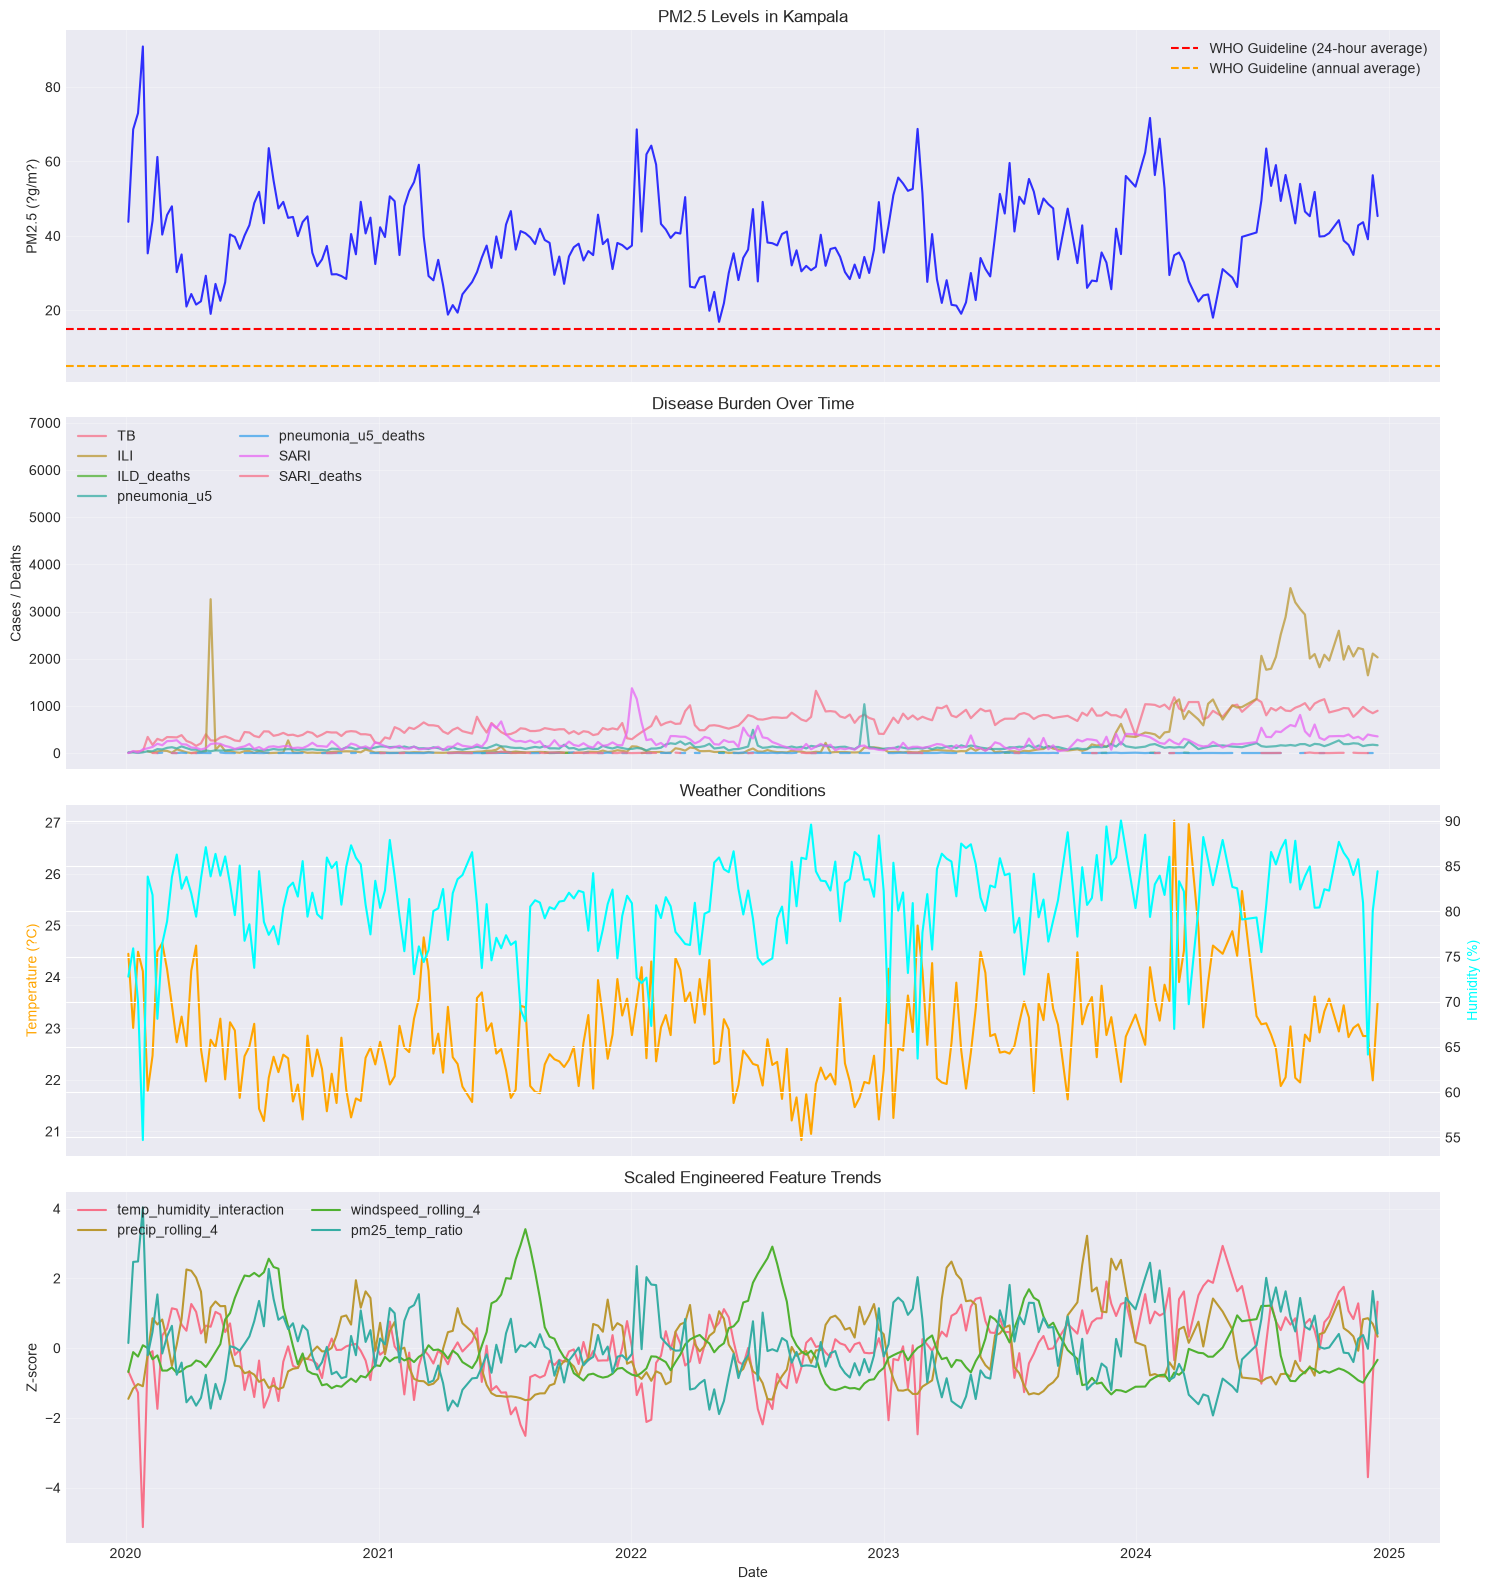

In [38]:
# Time series overview for air quality, diseases, and weather
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

axes[0].plot(processed_data['date'], processed_data['pm2_5'], color='blue', alpha=0.8)
axes[0].axhline(y=15, color='red', linestyle='--', label='WHO Guideline (24-hour average)')
axes[0].axhline(y=5, color='orange', linestyle='--', label='WHO Guideline (annual average)')
axes[0].set_title('PM2.5 Levels in Kampala')
axes[0].set_ylabel('PM2.5 (?g/m?)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for disease in disease_cols:
    axes[1].plot(processed_data['date'], processed_data[disease], alpha=0.75, linewidth=1.6, label=disease)
axes[1].set_title('Disease Burden Over Time')
axes[1].set_ylabel('Cases / Deaths')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(True, alpha=0.3)

ax2_twin = axes[2].twinx()
axes[2].plot(processed_data['date'], processed_data['avgtemp'], color='orange', label='Temperature')
ax2_twin.plot(processed_data['date'], processed_data['avghumidity'], color='cyan', label='Humidity')
axes[2].set_title('Weather Conditions')
axes[2].set_ylabel('Temperature (?C)', color='orange')
ax2_twin.set_ylabel('Humidity (%)', color='cyan')
axes[2].grid(True, alpha=0.3)

engineered_plot_cols = [
    col for col in ['temp_humidity_interaction', 'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio']
    if col in processed_data.columns
]
engineered_scaled = processed_data[engineered_plot_cols].copy()
for col in engineered_plot_cols:
    col_std = engineered_scaled[col].std()
    if pd.notna(col_std) and col_std != 0:
        engineered_scaled[col] = (engineered_scaled[col] - engineered_scaled[col].mean()) / col_std
    else:
        engineered_scaled[col] = 0
for col in engineered_plot_cols:
    axes[3].plot(processed_data['date'], engineered_scaled[col], linewidth=1.5, label=col)
axes[3].set_title('Scaled Engineered Feature Trends')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left', ncol=2)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


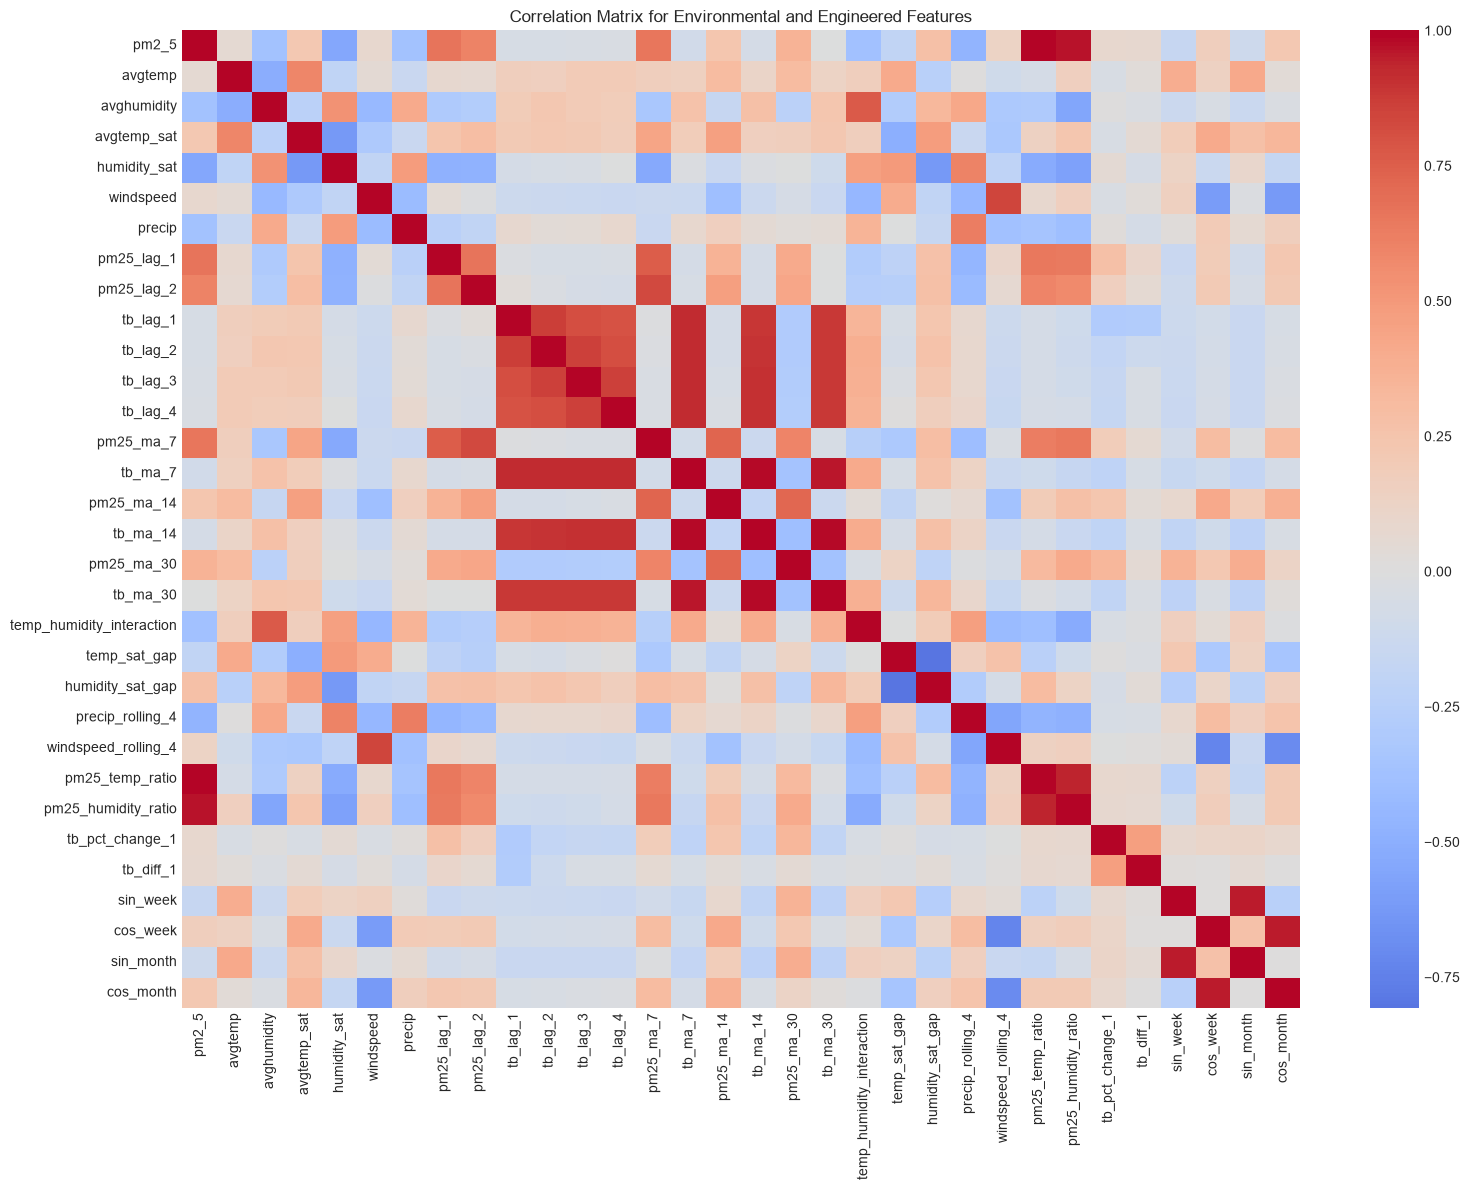

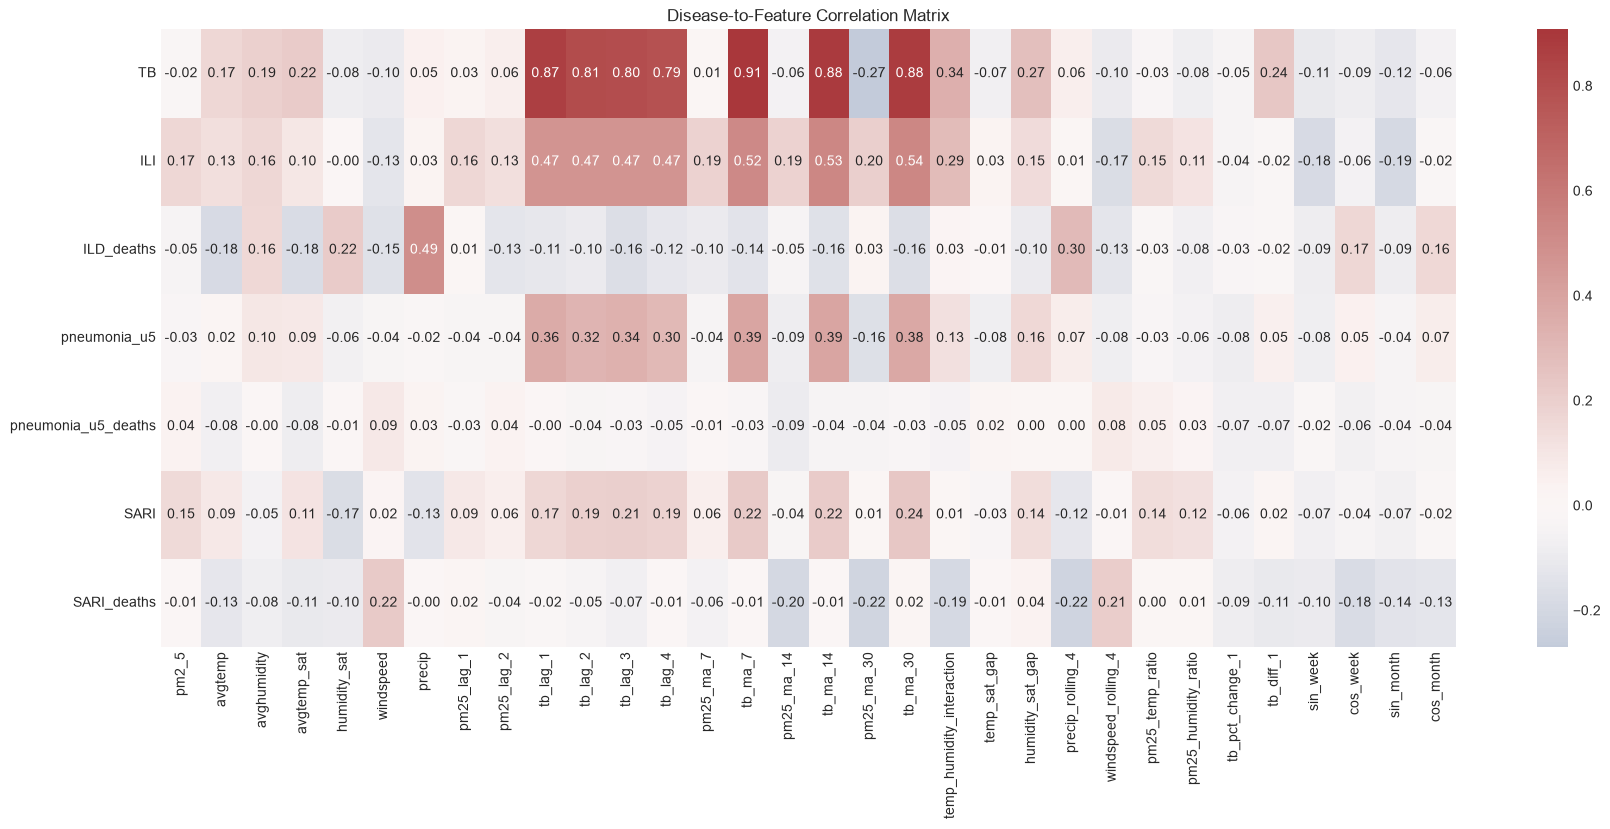

In [39]:
# Correlation analysis across diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

feature_corr_matrix = processed_data[feature_analysis_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(feature_corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Environmental and Engineered Features')
plt.tight_layout()
plt.show()

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
plt.figure(figsize=(18, max(4, len(disease_cols) * 1.2)))
sns.heatmap(disease_feature_corr, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Disease-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [40]:
# Disease-level feature ranking and pairwise relationships
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
strongest_links = (
    disease_feature_corr.abs()
    .stack()
    .reset_index(name='abs_correlation')
    .rename(columns={'level_0': 'disease', 'level_1': 'feature'})
    .sort_values(['disease', 'abs_correlation'], ascending=[True, False])
    .groupby('disease')
    .head(5)
)
strongest_links['correlation'] = strongest_links.apply(
    lambda row: disease_feature_corr.loc[row['disease'], row['feature']],
    axis=1
)
print('Top 5 absolute correlations per disease')
print(strongest_links[['disease', 'feature', 'correlation', 'abs_correlation']].to_string(index=False))

summary_stats = processed_data[disease_cols + feature_analysis_cols].describe().T[['mean', 'std', 'min', 'max']].round(2)
summary_stats.head(20)


Top 5 absolute correlations per disease
            disease             feature  correlation  abs_correlation
         ILD_deaths              precip     0.493361         0.493361
         ILD_deaths    precip_rolling_4     0.296231         0.296231
         ILD_deaths        humidity_sat     0.219189         0.219189
         ILD_deaths             avgtemp    -0.183328         0.183328
         ILD_deaths         avgtemp_sat    -0.179424         0.179424
                ILI            tb_ma_30     0.537401         0.537401
                ILI            tb_ma_14     0.531085         0.531085
                ILI             tb_ma_7     0.518582         0.518582
                ILI            tb_lag_1     0.473442         0.473442
                ILI            tb_lag_4     0.473301         0.473301
               SARI            tb_ma_30     0.236131         0.236131
               SARI             tb_ma_7     0.223349         0.223349
               SARI            tb_ma_14     0.2189

,mean,std,min,max
TB,638.257143,251.800953,7.0,1321.0
ILI,339.95082,724.514583,1.0,3498.0
ILD_deaths,132.125,904.011465,1.0,6775.0
pneumonia_u5,124.112903,75.613519,4.0,1037.0
pneumonia_u5_deaths,3.403141,3.289503,1.0,19.0
SARI,220.125,161.489839,1.0,1375.0
SARI_deaths,3.95614,4.435158,1.0,31.0
pm2_5,39.280081,11.806612,16.87,90.92
avgtemp,22.851992,0.969116,20.83,27.04
avghumidity,80.956842,5.046416,54.71,90.06


In [41]:
# --- 1. Data Preprocessing ---

# Convert 'date' to datetime and set as index
data_itsa = processed_data.copy()
data_itsa['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')
data_itsa = data_itsa.sort_values('date').set_index('date')

In [42]:
# --- 2. Handle Missing Data ---

# Check for missing values before handling them
print("--- Missing Values Before Handling ---")
print(data_itsa.isnull().sum())

# Use forward fill to handle missing values, a common method for time series
data_itsa.fillna(value=0, inplace=True)

# Verify that missing values are handled
print("\n--- Missing Values After Forward Fill ---")
print(data.isnull().sum())


--- Missing Values Before Handling ---
epi_year            0
epi_week            0
epi_week_label_x    0
avgtemp_sat         0
windspeed           0
                   ..
tb_diff_1           1
sin_week            0
cos_week            0
sin_month           0
cos_month           0
Length: 67, dtype: int64

--- Missing Values After Forward Fill ---
epi_year                  0
epi_week                  0
epi_week_label_x          0
avgtemp_sat               0
windspeed                 0
precip                    0
humidity_sat              0
epi_week_label_y          0
pm2_5                     0
avgtemp                   0
avghumidity               0
readings_per_week         0
date                      0
ILI                       4
ILD_deaths              192
pneumonia_u5              0
pneumonia_u5_deaths      57
SARI                      0
SARI_deaths             134
TB                        0
year_month                0
county                    0
avg_pm2_5_calibrated      0
total_t

In [43]:
# --- 3. Define the Intervention Point ---

# Find the halfway point in the data
intervention_point = len(data_itsa) // 2
intervention_date = data_itsa.index[intervention_point]

print(f"\nThe dataset has {len(data_itsa)} data points.")
print(f"The intervention is set at index {intervention_point}, which correspondate to the date: {intervention_date.date()}")



The dataset has 248 data points.
The intervention is set at index 124, which correspondate to the date: 2022-05-29


In [44]:
# --- 4. Create Interrupted Time Series (ITS) Variables ---

# Time variable: a sequence from 1 to the number of observations
data_itsa['time'] = np.arange(1, len(data_itsa) + 1)

# Intervention variable: 0 before the intervention, 1 after
data_itsa['intervention'] = (data_itsa.index >= intervention_date).astype(int)

# Time since intervention: 0 before, and counts up from 1 after the intervention
data_itsa['time_since_intervention'] = 0
post_intervention_indices = data_itsa[data_itsa['intervention'] == 1].index
time_since_intervention_values = np.arange(len(post_intervention_indices))
data_itsa.loc[post_intervention_indices, 'time_since_intervention'] = time_since_intervention_values

In [45]:
# --- 5. LSTM Modeling for predicted_tb ---

feature_cols = [
    'TB', 'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
    'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
    'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
    'pm25_ma_30', 'tb_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
    'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
    'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
    'time_since_intervention'
]

sequence_length = 8
lstm_df = data_itsa[feature_cols].copy().fillna(0)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(lstm_df)
scaled_target = target_scaler.fit_transform(data_itsa[['TB']])

def build_sequences(features, target, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i-seq_len:i])
        y_seq.append(target[i])
    return np.array(X_seq), np.array(y_seq)

X_all, y_all = build_sequences(scaled_features, scaled_target, sequence_length)
train_end = max(sequence_length + 1, intervention_point)
X_train, y_train = X_all[:train_end-sequence_length], y_all[:train_end-sequence_length]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, X_all.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stopping]
)

pred_scaled = lstm_model.predict(X_all, verbose=0)
pred_tb = target_scaler.inverse_transform(pred_scaled).flatten()

data_itsa['predicted_tb'] = data_itsa['TB'].astype(float)
data_itsa.iloc[sequence_length:, data_itsa.columns.get_loc('predicted_tb')] = pred_tb

counterfactual_features = lstm_df.copy()
counterfactual_features.loc[counterfactual_features.index >= intervention_date, 'intervention'] = 0
counterfactual_features.loc[counterfactual_features.index >= intervention_date, 'time_since_intervention'] = 0
scaled_counterfactual = feature_scaler.transform(counterfactual_features.fillna(0))
X_counterfactual, _ = build_sequences(scaled_counterfactual, scaled_target, sequence_length)
counter_scaled = lstm_model.predict(X_counterfactual, verbose=0)
counter_tb = target_scaler.inverse_transform(counter_scaled).flatten()

data_itsa['counterfactual_tb'] = data_itsa['TB'].astype(float)
data_itsa.iloc[sequence_length:, data_itsa.columns.get_loc('counterfactual_tb')] = counter_tb

actual_for_metrics = data_itsa['TB'].iloc[sequence_length:]
pred_for_metrics = data_itsa['predicted_tb'].iloc[sequence_length:]
rmse = np.sqrt(mean_squared_error(actual_for_metrics, pred_for_metrics))
mae = mean_absolute_error(actual_for_metrics, pred_for_metrics)

print("\n--- LSTM Model Summary ---")
print(f"Features used: {len(feature_cols)}")
print(f"Sequence length: {sequence_length} weeks")
print(f"Training windows: {len(X_train)}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


--- LSTM Model Summary ---
Features used: 36
Sequence length: 8 weeks
Training windows: 116
Best validation loss: 0.011399
RMSE: 157.00
MAE: 116.22


In [46]:
# Make sure the index is datetime
data_itsa.index = pd.to_datetime(data_itsa.index, errors='coerce')


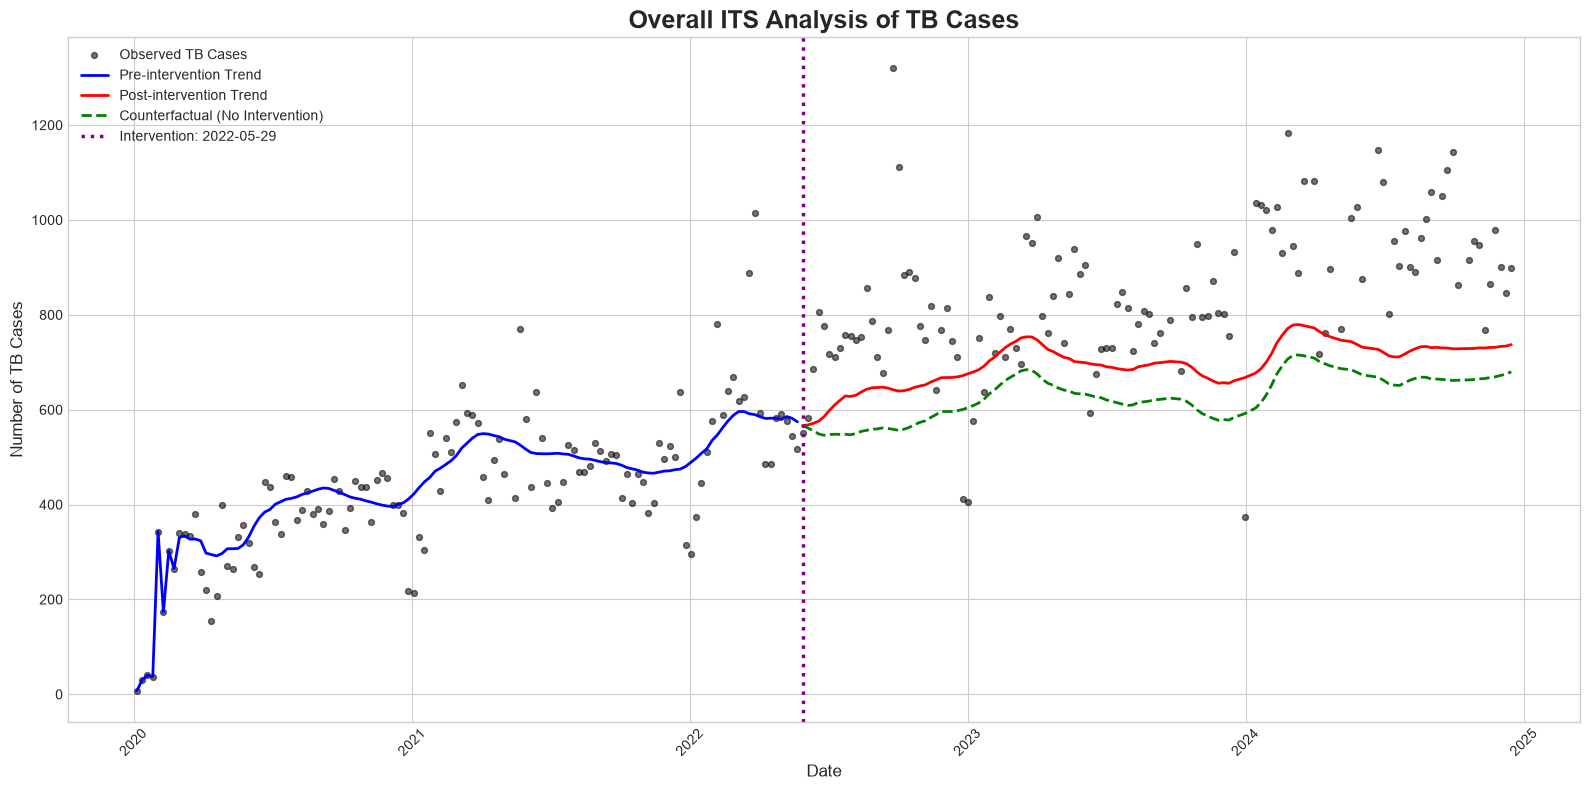

In [47]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(16, 8))

# Observed TB cases
ax.scatter(data_itsa.index, data_itsa['TB'], color='black', alpha=0.55, label='Observed TB Cases', s=18)

# Predicted trend before and after the intervention
pre_data = data_itsa[data_itsa['intervention'] == 0]
post_data = data_itsa[data_itsa['intervention'] == 1]
ax.plot(pre_data.index, pre_data['predicted_tb'], color='blue', linewidth=2, label='Pre-intervention Trend')
ax.plot(post_data.index, post_data['predicted_tb'], color='red', linewidth=2, label='Post-intervention Trend')

# Counterfactual after intervention
ax.plot(post_data.index, post_data['counterfactual_tb'], color='green', linestyle='--', linewidth=2, label='Counterfactual (No Intervention)')

# Intervention marker
ax.axvline(x=intervention_date, color='purple', linestyle=':', linewidth=2.5, label=f'Intervention: {intervention_date.date()}')

# Formatting
ax.set_title('Overall ITS Analysis of TB Cases', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of TB Cases', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


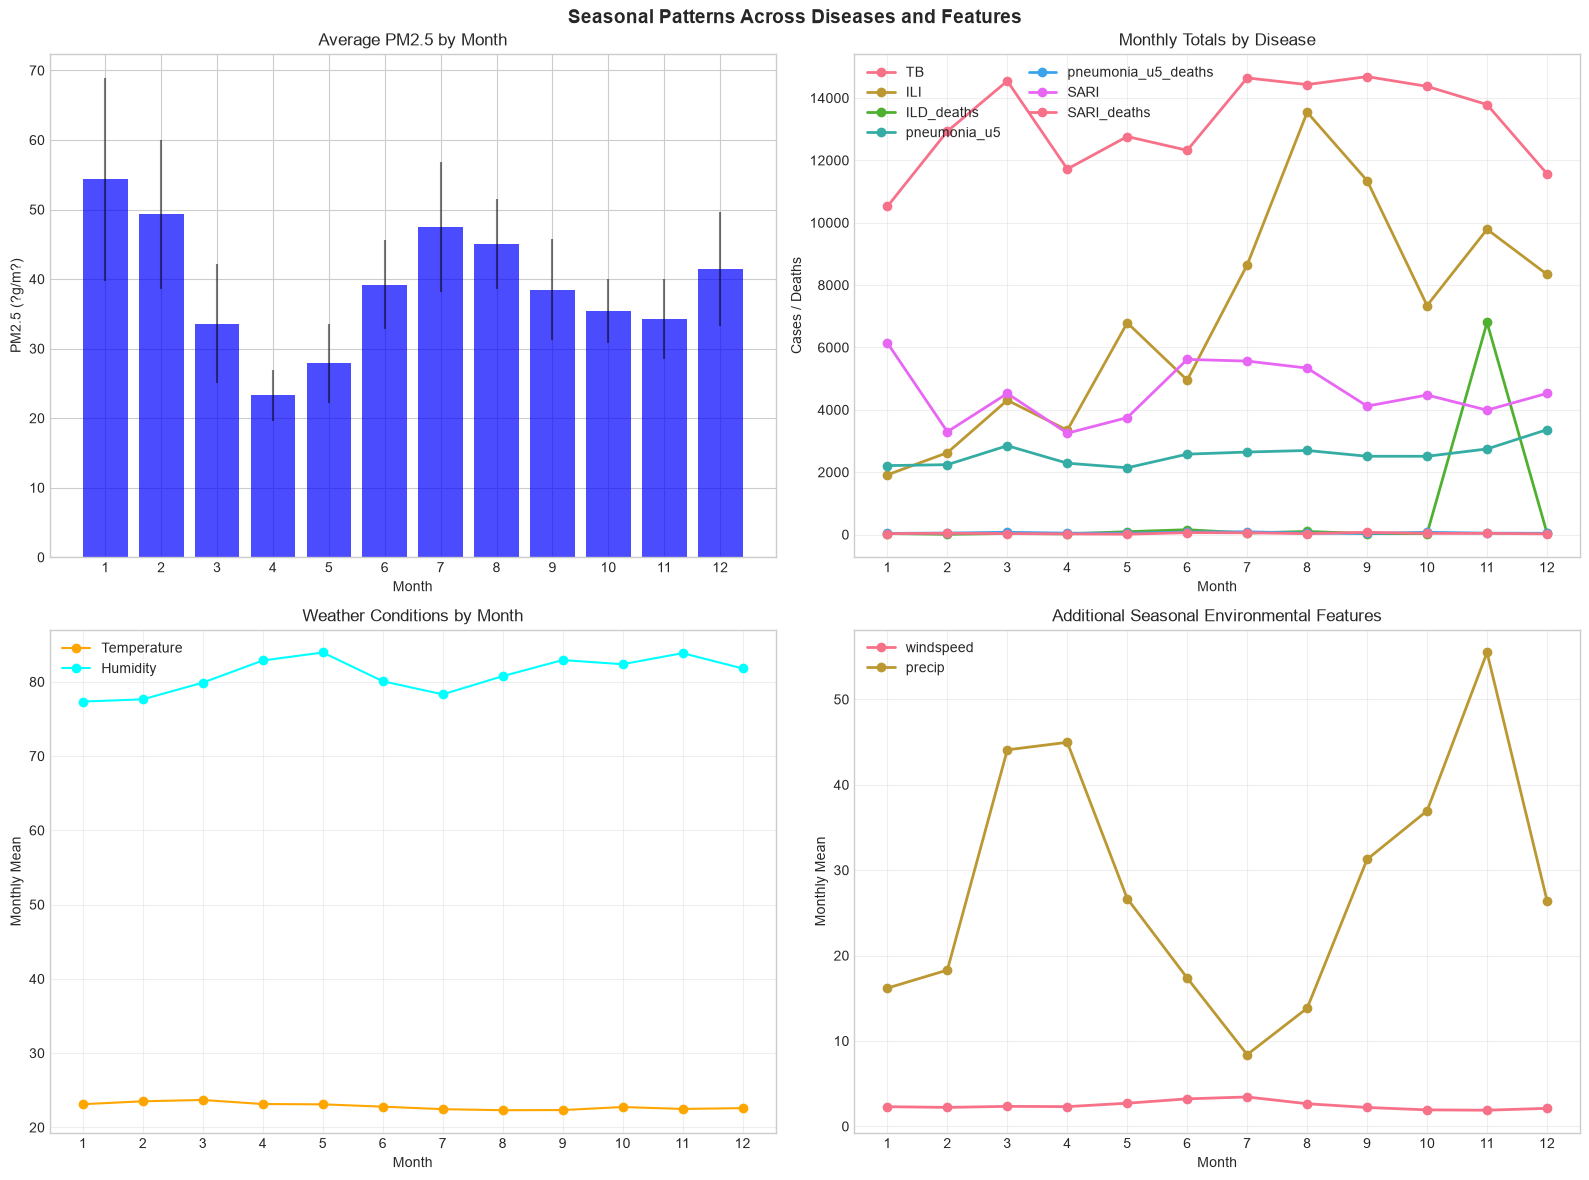

,TB,ILI,ILD_deaths,pneumonia_u5,pneumonia_u5_deaths,SARI,SARI_deaths
month,,,,,,,
1,10520.26,1914.0,33.0,2211,37.0,6143,31.0
2,12933.00,2626.0,7.0,2241,48.0,3297,40.0
3,14544.00,4307.0,34.0,2849,72.0,4524,31.0
4,11721.00,3346.0,21.0,2288,45.0,3250,22.0
5,12763.00,6790.0,92.0,2141,41.0,3750,12.0
6,12321.26,4954.0,155.0,2578,81.0,5616,61.0
7,14643.00,8647.0,49.0,2646,88.0,5563,57.0
8,14429.00,13540.0,99.0,2696,46.0,5338,29.0
9,14685.00,11349.0,30.0,2511,36.0,4119,72.0


In [48]:
# Monthly patterns across all diseases and key features
processed_data['month'] = processed_data['date'].dt.month
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
monthly_feature_cols = [
    col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in processed_data.columns
]
monthly_agg = {col: ['mean', 'std'] for col in monthly_feature_cols}
monthly_agg.update({col: ['mean', 'sum'] for col in disease_cols})
monthly_stats = processed_data.groupby('month').agg(monthly_agg).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(range(1, 13), monthly_stats['pm2_5']['mean'].values, color='blue', alpha=0.7)
axes[0, 0].errorbar(
    range(1, 13),
    monthly_stats['pm2_5']['mean'].values,
    yerr=monthly_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (?g/m?)')
axes[0, 0].set_xticks(range(1, 13))

for disease in disease_cols:
    axes[0, 1].plot(range(1, 13), monthly_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Monthly Totals by Disease')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Cases / Deaths')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(1, 13), monthly_stats['avgtemp']['mean'].values, 'o-', color='orange', label='Temperature')
axes[1, 0].plot(range(1, 13), monthly_stats['avghumidity']['mean'].values, 'o-', color='cyan', label='Humidity')
axes[1, 0].set_title('Weather Conditions by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Monthly Mean')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

seasonal_feature_cols = [
    col for col in ['windspeed', 'precip']
    if col in processed_data.columns
]
for col in seasonal_feature_cols:
    axes[1, 1].plot(range(1, 13), monthly_stats[col]['mean'].values, marker='o', linewidth=2, label=col)
axes[1, 1].set_title('Additional Seasonal Environmental Features')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Monthly Mean')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Seasonal Patterns Across Diseases and Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

monthly_disease_totals = monthly_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
monthly_disease_totals.columns = [col for col, _ in monthly_disease_totals.columns]
monthly_disease_totals


In [49]:
data_project = processed_data.copy()
data_project = data_project[["date", "TB"]]
data_project = data_project.rename(columns={"TB": "y"})
data_project['date'] = pd.to_datetime(data_project['date'], format='%d/%m/%Y')

## Step 5: Time Series Modeling


In [50]:

# Prepare data for additional time-series model comparison

data_predict = processed_data.copy()
data_predict['date'] = pd.to_datetime(data_predict['date'], errors='coerce')
data_predict = data_predict.sort_values('date')

model_feature_cols = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2', 'tb_lag_3', 'tb_lag_4',
    'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14', 'pm25_ma_30', 'tb_ma_30',
    'sin_week', 'cos_week', 'sin_month', 'cos_month'
]

available_model_features = [col for col in model_feature_cols if col in data_predict.columns]
print(f'Available model features: {len(available_model_features)}')
print(available_model_features)


Available model features: 30
['pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip', 'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2', 'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14', 'pm25_ma_30', 'tb_ma_30', 'sin_week', 'cos_week', 'sin_month', 'cos_month']


In [51]:

# Build a compact benchmark using the local time series modeler

ts_modeler = TimeSeriesModeler(data_predict, target_column='TB')
X_ts, y_ts = ts_modeler.prepare_time_series_data(
    window_size=8,
    features=available_model_features,
    target_type='binary'
)

print('Prepared time-series benchmark arrays:')
print('X shape:', X_ts.shape)
print('y shape:', y_ts.shape)


INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: TB
INFO:time_series_modeler:Prepared 240 samples with 240 features


Prepared time-series benchmark arrays:
X shape: (240, 240)
y shape: (240,)


In [52]:

benchmark_results = ts_modeler.train_models(
    X_ts,
    y_ts,
    models_to_train=['random_forest', 'gradient_boosting', 'svm'],
    cv_splits=3
)

if benchmark_results:
    models_performance = pd.DataFrame([
        {
            'Model': model_name,
            'Accuracy': metrics.get('mean_accuracy', np.nan),
            'F1 Score': metrics.get('mean_f1', np.nan),
            'Precision': metrics.get('mean_precision', np.nan),
            'Recall': metrics.get('mean_recall', np.nan)
        }
        for model_name, metrics in benchmark_results.items()
    ]).sort_values('F1 Score', ascending=False)
else:
    models_performance = pd.DataFrame(columns=['Model', 'Accuracy', 'F1 Score', 'Precision', 'Recall'])

models_performance


INFO:time_series_modeler:Training random_forest...
INFO:time_series_modeler:Training gradient_boosting...


ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:

# Compare the benchmark models against the LSTM regression metrics already computed
print('--- Model Comparison Summary ---')
if not models_performance.empty:
    print(models_performance.round(3).to_string(index=False))
else:
    print('No benchmark models were trained.')

print(f'
LSTM Regression RMSE: {rmse:.2f}')
print(f'LSTM Regression MAE: {mae:.2f}')


## Step 4: Intervention Simulation


In [ ]:

# Get baseline metrics
baseline = processor.get_intervention_baseline()
print('Baseline Metrics:')
print(f"- Average PM2.5: {baseline['baseline_pm25']:.2f}")
print(f"- Average TB cases: {baseline['baseline_tb']:.2f}")
print(f"- Total TB cases: {baseline['total_tb_cases']:.2f}")
print(f"- PM2.5-TB correlation: {baseline['correlation']:.3f}")


In [ ]:

# Simulate intervention scenarios
scenarios = {
    'Traffic Control': {'reduction': 0.25, 'cost_factor': 2.5},
    'Green Spaces': {'reduction': 0.15, 'cost_factor': 3.0},
    'Dust Control': {'reduction': 0.20, 'cost_factor': 4.0},
    'Combined': {'reduction': 0.35, 'cost_factor': 5.0}
}

cr_tb = 1.08  # Relative risk per 10 ?g/m?
results = []
for scenario_name, params in scenarios.items():
    reduced_pm25 = baseline['baseline_pm25'] * (1 - params['reduction'])
    pm25_change = reduced_pm25 - baseline['baseline_pm25']
    relative_risk = cr_tb ** (pm25_change / 10)
    tb_cases_baseline = baseline['total_tb_cases']
    tb_cases_with_intervention = tb_cases_baseline * relative_risk
    tb_cases_prevented = tb_cases_baseline - tb_cases_with_intervention
    cost = params['cost_factor'] * 1_000_000
    cost_per_case = cost / tb_cases_prevented if tb_cases_prevented > 0 else np.inf
    results.append({
        'Scenario': scenario_name,
        'PM2.5 Reduction (%)': params['reduction'] * 100,
        'Final PM2.5 (?g/m?)': reduced_pm25,
        'TB Cases Prevented': tb_cases_prevented,
        'Cost Factor': params['cost_factor'],
        'Cost per Case Prevented ($)': cost_per_case
    })

results_df = pd.DataFrame(results)
results_df


In [ ]:

# Visualize intervention impacts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    results_df['PM2.5 Reduction (%)'],
    results_df['TB Cases Prevented'],
    s=results_df['Cost Factor'] * 60,
    alpha=0.7,
    c=range(len(results_df)),
    cmap='viridis'
)
for i, txt in enumerate(results_df['Scenario']):
    axes[0].annotate(
        txt,
        (results_df['PM2.5 Reduction (%)'].iloc[i], results_df['TB Cases Prevented'].iloc[i])
    )
axes[0].set_xlabel('PM2.5 Reduction (%)')
axes[0].set_ylabel('TB Cases Prevented')
axes[0].set_title('Intervention Effectiveness')
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    results_df['Scenario'],
    results_df['Cost per Case Prevented ($)'],
    color=['blue', 'green', 'orange', 'red'],
    alpha=0.7
)
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Cost per Case Prevented ($)')
axes[1].set_title('Cost-Effectiveness Analysis')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Step 6: Generate Report


In [ ]:
# Summary Report
print('=' * 60)
print('KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT')
print('=' * 60)
print()

disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

disease_totals = processed_data[disease_cols].sum().sort_values(ascending=False)
disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
strongest_links = []
for disease in disease_cols:
    strongest_feature = disease_feature_corr.loc[disease].abs().sort_values(ascending=False).index[0]
    strongest_value = disease_feature_corr.loc[disease, strongest_feature]
    strongest_links.append((disease, strongest_feature, strongest_value))

print('1. DATA OVERVIEW')
print('-' * 40)
print(f"   - Analysis Period: {summary['date_range']}")
print(f"   - Total Records: {summary['total_records']}")
print(f"   - Average PM2.5: {summary['pm25_statistics']['mean']:.2f} ?g/m?")
print(f"   - Diseases analyzed: {', '.join(disease_cols)}")
print()

print('2. DISEASE BURDEN')
print('-' * 40)
for disease, total in disease_totals.items():
    print(f"   - Total {disease}: {total:.2f}")
print()

print('3. KEY FEATURE RELATIONSHIPS')
print('-' * 40)
for disease, feature, value in strongest_links:
    print(f"   - {disease}: strongest correlation with {feature} ({value:.3f})")
print(f"   - TB LSTM RMSE: {rmse:.2f}")
print(f"   - TB LSTM MAE: {mae:.2f}")
print()

print('4. INTERVENTION RECOMMENDATIONS')
print('-' * 40)
best_scenario = results_df.loc[results_df['TB Cases Prevented'].idxmax()]
print(f"   - Most Effective: {best_scenario['Scenario']}")
print(f"   - PM2.5 Reduction: {best_scenario['PM2.5 Reduction (%)']:.1f}%")
print(f"   - TB Cases Prevented: {best_scenario['TB Cases Prevented']:.0f}")
print()

print('5. BENCHMARK MODEL PERFORMANCE')
print('-' * 40)
if not models_performance.empty:
    best_model = models_performance.iloc[0]
    print(f"   - Best Benchmark Model: {best_model['Model']}")
    print(f"   - Accuracy: {best_model['Accuracy']:.3f}")
    print(f"   - F1 Score: {best_model['F1 Score']:.3f}")
else:
    print('   - No benchmark classification models were trained.')
print()
print('=' * 60)

results_dir = Path('./results')
results_dir.mkdir(exist_ok=True)
results_df.to_csv(results_dir / 'intervention_scenarios.csv', index=False)
models_performance.to_csv(results_dir / 'model_performance.csv', index=False)
print('? Results saved to ./results/')
